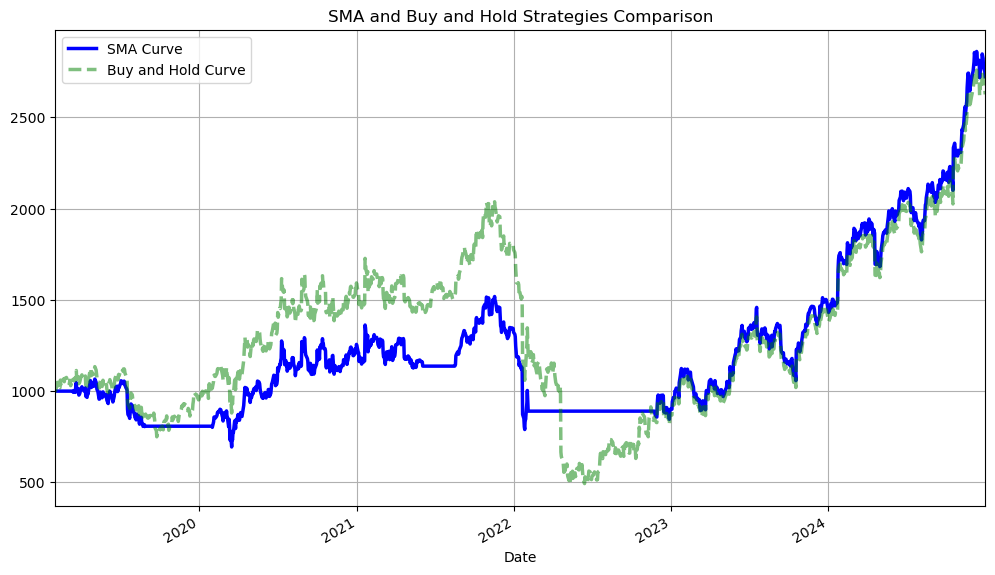

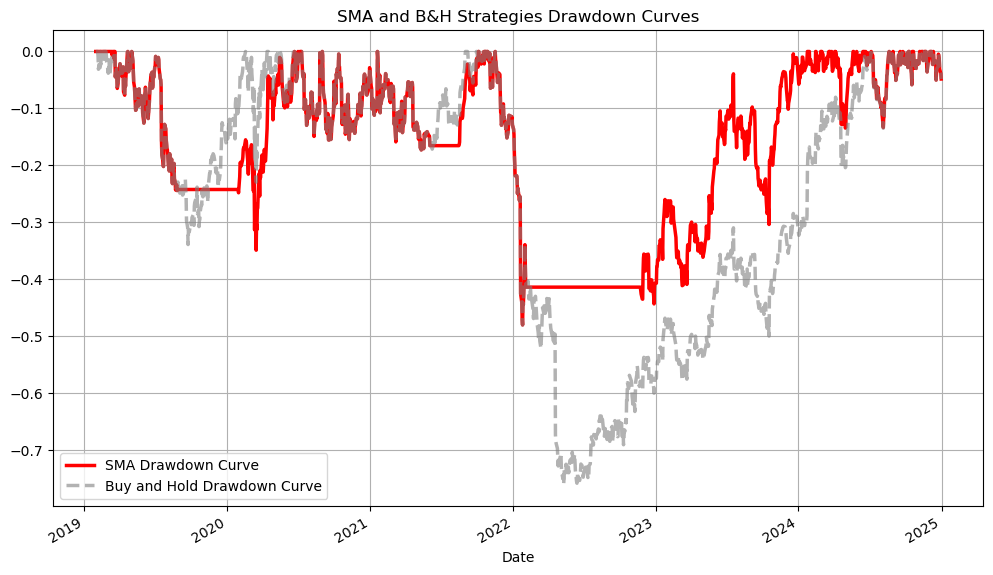

In [1]:
import numpy as np
import pandas as pd
from Fonctions import compute_metrics, drawdown
import matplotlib.pyplot as plt
%load_ext autoreload
%autoreload 2

data = pd.read_csv("NFLX_data.csv",index_col = 0, parse_dates = True, header=[0,1])
data_return = pd.read_csv("NFLX_data_return.csv", index_col =0, parse_dates = True).squeeze()
fifthy_mean = data["Close"]["NFLX"].rolling(50).mean()
two_hundered_mean = data["Close"]["NFLX"].rolling(200).mean()

signal = (fifthy_mean > two_hundered_mean).astype(int).shift(1)
strat = data_return * signal 
V0 = 1000
equity_curve = V0 * np.exp(strat.cumsum())
equity_curve = equity_curve["2019-01-31":]
equity_curve = equity_curve / equity_curve.iloc[0] * V0
equity_bandh = V0 * np.exp(data_return.cumsum())
equity_bandh = equity_bandh["2019-01-31":]
equity_bandh = equity_bandh / equity_bandh.iloc[0] * V0


plt.figure(figsize=(12,7))
equity_curve.plot(color="blue",linewidth = 2.5, label = "SMA Curve")
equity_bandh.plot(color="green", linewidth = 2.5, label = "Buy and Hold Curve",linestyle = '--', alpha = 0.5)
plt.title("SMA and Buy and Hold Strategies Comparison")
plt.grid()
plt.legend()
plt.xlim(equity_curve.index[0], equity_curve.index[-1])
plt.show()
data_return_filtered = data_return["2019-01-31":]
strat_filtered = strat["2019-01-31":]

plt.figure(figsize = (12,7))
drawdown(equity_curve).plot(color = "red", linewidth = 2.5, label = "SMA Drawdown Curve")
drawdown(equity_bandh).plot(color = "grey", linewidth = 2.5, linestyle = "--", label = "Buy and Hold Drawdown Curve", alpha = 0.6)
plt.title ("SMA and B&H Strategies Drawdown Curves")
plt.grid()
plt.legend()
plt.show()

pd.DataFrame({
    "SMA Crossover": compute_metrics(strat_filtered, equity_curve,freq="daily"),
    "Buy and Hold": compute_metrics(data_return_filtered, equity_bandh,freq="daily")
})

compute_metrics(strat_filtered, equity_curve, freq="daily").to_csv("metrics_sma.csv")